In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import scipy as scp

In [ ]:
titanic = pd.read_csv("./Titanic-Dataset.csv") 
titanic = titanic.loc[:, ["Age", "Fare", "Survived"]]
titanic.sample(10)

,Age,Fare,Survived
431,NaN,16.1000,1
350,23.0,9.2250,0
788,1.0,20.5750,1
413,NaN,0.0000,0
647,56.0,35.5000,1
57,28.5,7.2292,0
28,NaN,7.8792,1
872,33.0,5.0000,0
317,54.0,14.0000,0
202,34.0,6.4958,0


In [98]:
titanic = titanic.dropna()
titanic.isnull().sum()

Age         0
Fare        0
Survived    0
dtype: int64

In [99]:
x = titanic.iloc[::, :2:]
y = titanic.iloc[::, -1]

In [100]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(x, y, test_size= 0.2, random_state= 42)

In [101]:
dtc = skl.tree.DecisionTreeClassifier()

dtc.fit(x_train, y_train)

y_pred = dtc.predict(x_test)

skl.metrics.accuracy_score(y_test, y_pred)

0.6363636363636364

In [102]:
np.mean(skl.model_selection.cross_val_score(skl.tree.DecisionTreeClassifier(), x, y, scoring= "accuracy", cv= 10))

np.float64(0.6358959311424099)

In [108]:
trf = skl.compose.ColumnTransformer(transformers= [       # We can use kmeans, quanile, uniform as strategy
    ("first",skl.preprocessing.KBinsDiscretizer(n_bins= 20, strategy="quantile",encode= "ordinal") , ["Age"]),
    ("second",skl.preprocessing.KBinsDiscretizer(n_bins= 20, strategy="quantile",encode= "ordinal") , ["Fare"])
])

x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

In [109]:
trf.named_transformers_["first"].n_bins_

array([20])

In [110]:
trf.named_transformers_["second"].bin_edges_

array([array([  0.    ,   7.2292,   7.75  ,   7.8542,   7.8958,   8.05  ,
                9.225 ,  10.5   ,  13.    ,  13.4167,  15.75  ,  20.25  ,
               26.    ,  26.55  ,  29.125 ,  34.375 ,  51.4792,  69.3   ,
               82.1708, 134.5   , 512.3292])                             ],
      dtype=object)

In [111]:
output = pd.DataFrame({
    "age": x_train["Age"],
    "age_trf": x_train_trf[:, 0],
    "fare": x_train["Fare"],
    "fare_trf": x_train_trf[:, 1]
})
output

,age,age_trf,fare,fare_trf
328,31.0,11.0,20.5250,11.0
73,26.0,8.0,14.4542,9.0
253,30.0,11.0,16.1000,10.0
719,33.0,12.0,7.7750,2.0
666,25.0,8.0,13.0000,8.0
...,...,...,...,...
92,46.0,17.0,61.1750,16.0
134,25.0,8.0,13.0000,8.0
337,41.0,15.0,134.5000,19.0
548,33.0,12.0,20.5250,11.0


In [112]:
dtc = skl.tree.DecisionTreeClassifier()
dtc.fit(x_train_trf, y_train)
y_pred_trf = dtc.predict(x_test)
skl.metrics.accuracy_score(y_test, y_pred_trf)

c:\Users\aliab\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


0.6713286713286714

In [113]:
np.mean(skl.model_selection.cross_val_score(skl.tree.DecisionTreeClassifier(), x, y, scoring= "accuracy", cv= 10))

np.float64(0.6303012519561815)

In [114]:
x_train_trf = pd.DataFrame(data= x_train_trf, columns= x_train.columns)

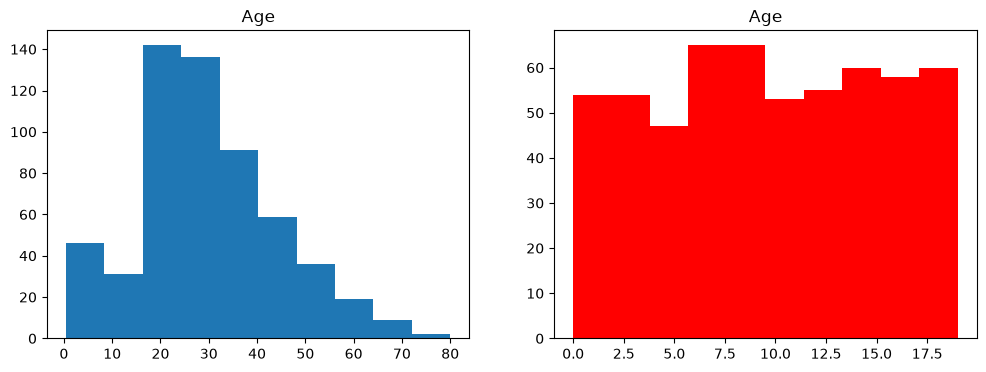

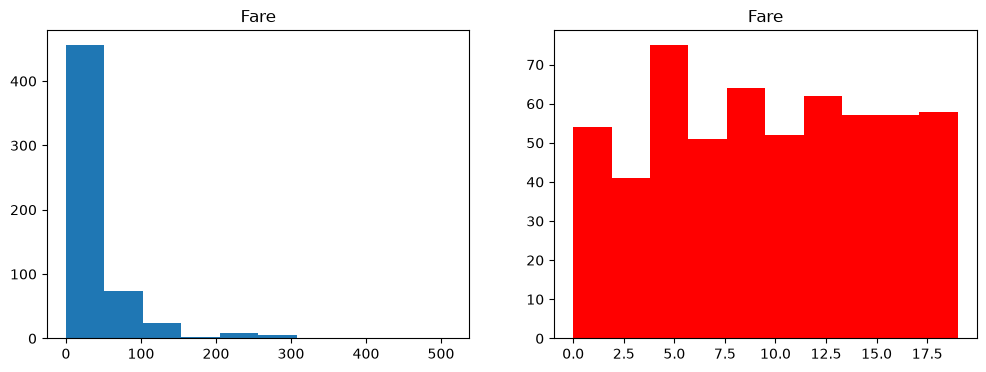

In [117]:
for col in x_train_trf.columns:
    plt.figure(figsize=(12, 4))
    
    plt.subplot(121)
    plt.hist(x_train[col])
    plt.title(col)
    
    plt.subplot(122)
    plt.hist(x_train_trf[col], color= "r")
    plt.title(col)
    
    plt.show()